# Week 1 — Introduction to Machine Learning
**Course:** 21CSC305P Machine Learning · **Unit 1 – Introduction**

**Topics covered:** what & why of ML · supervised vs. unsupervised learning · polynomial curve fitting · probability theory
(discrete random variables, fundamental rules, Bayes' rule, independence & conditional independence, continuous random variables,
quantiles, mean & variance, probability densities, expectation & covariance).

**Practice tasks**
1. Devise a program to import, load and view a dataset
2. Create a program to display the summary and statistics of the dataset

The notebook first builds the theory with small, runnable experiments (Part A), then does the two practice tasks (Part B).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
from sklearn.datasets import load_iris, load_wine

np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

## Part A — Theory in code

### A1. What is machine learning, and why?
Machine learning builds programs whose behaviour is **learned from data** instead of hand-coded. It is useful when the rules are
too complex to write down (vision, speech), when they change over time (spam), or when we want to discover structure in data.

| | Supervised learning | Unsupervised learning |
|---|---|---|
| Data | inputs **x** *and* targets *t* | inputs **x** only |
| Goal | predict *t* for new **x** (regression / classification) | discover structure (clustering, density estimation, dimensionality reduction) |
| Example | iris species from petal size | grouping flowers without knowing the species |

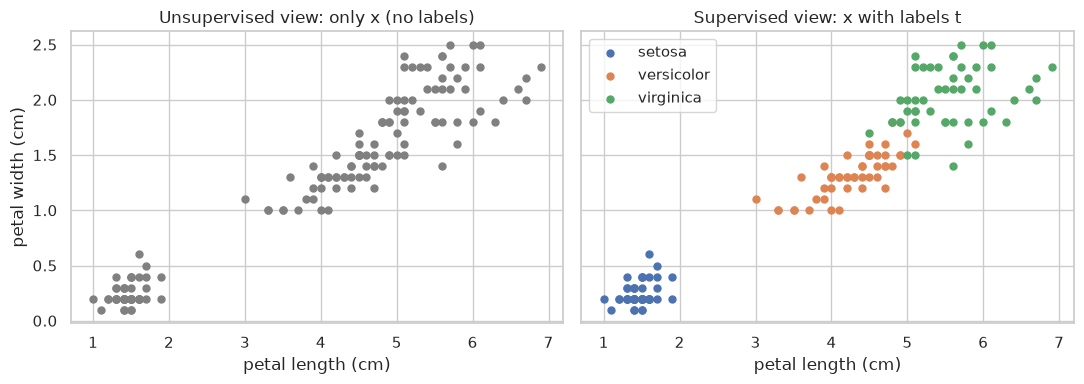

In [2]:
iris = load_iris(as_frame=True)
X = iris.frame[["petal length (cm)", "petal width (cm)"]]
y = iris.target
names = iris.target_names

fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
ax[0].scatter(X.iloc[:, 0], X.iloc[:, 1], c="gray", s=25)
ax[0].set_title("Unsupervised view: only x (no labels)")
for k, name in enumerate(names):
    m = y == k
    ax[1].scatter(X.loc[m].iloc[:, 0], X.loc[m].iloc[:, 1], s=25, label=name)
ax[1].set_title("Supervised view: x with labels t")
ax[1].legend()
for a in ax:
    a.set_xlabel("petal length (cm)")
ax[0].set_ylabel("petal width (cm)")
plt.tight_layout(); plt.show()

### A2. Polynomial curve fitting (Bishop §1.1)
Data are generated as $t = \sin(2\pi x) + \varepsilon$ with Gaussian noise. We fit
$y(x, \mathbf{w}) = \sum_{j=0}^{M} w_j x^j$ by minimising the sum-of-squares error
$E(\mathbf{w}) = \tfrac12 \sum_n \{y(x_n,\mathbf{w}) - t_n\}^2$.
Low $M$ **under-fits**, high $M$ **over-fits** (it passes through the noise).

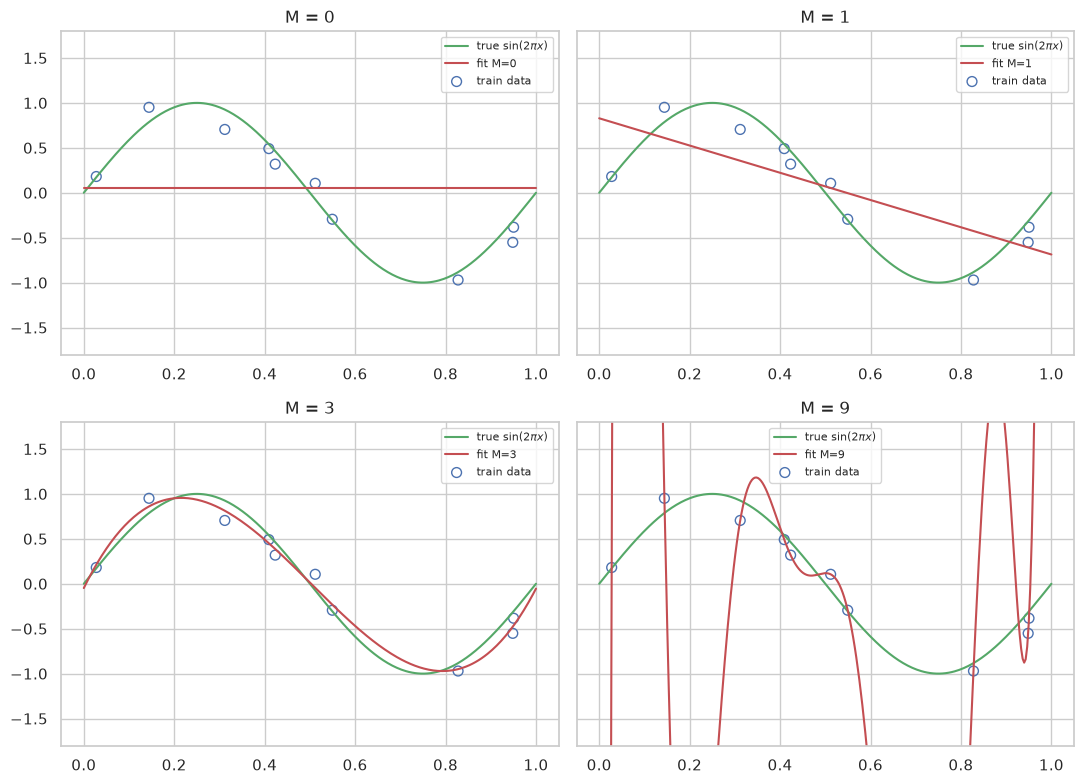

In [3]:
def make_data(N, noise=0.3, seed=0):
    r = np.random.default_rng(seed)
    x = np.sort(r.uniform(0, 1, N))
    return x, np.sin(2 * np.pi * x) + r.normal(0, noise, N)

x_train, t_train = make_data(10, seed=1)
x_test,  t_test  = make_data(100, seed=2)
x_line = np.linspace(0, 1, 300)

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=True)
for ax, M in zip(axes.ravel(), [0, 1, 3, 9]):
    w = np.polyfit(x_train, t_train, M)
    ax.plot(x_line, np.sin(2 * np.pi * x_line), "g", label=r"true $\sin(2\pi x)$")
    ax.plot(x_line, np.polyval(w, x_line), "r", label=f"fit M={M}")
    ax.scatter(x_train, t_train, facecolors="none", edgecolors="b", s=50, label="train data")
    ax.set_title(f"M = {M}"); ax.set_ylim(-1.8, 1.8); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

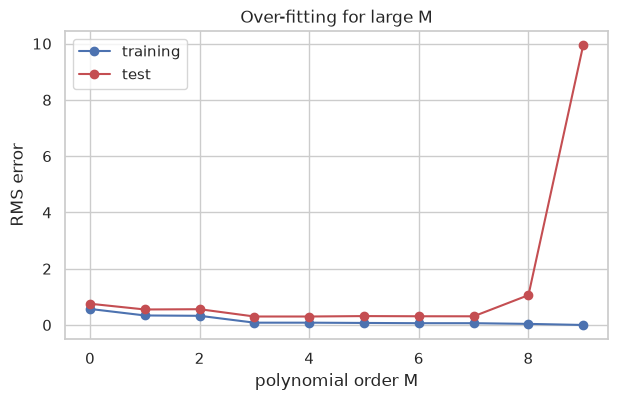

In [4]:
# Train vs test RMS error as a function of model complexity M
def rmse(w, x, t): return np.sqrt(np.mean((np.polyval(w, x) - t) ** 2))

Ms = range(0, 10)
tr, te = [], []
for M in Ms:
    w = np.polyfit(x_train, t_train, M)
    tr.append(rmse(w, x_train, t_train)); te.append(rmse(w, x_test, t_test))

plt.figure(figsize=(7, 4))
plt.plot(Ms, tr, "o-b", label="training"); plt.plot(Ms, te, "o-r", label="test")
plt.xlabel("polynomial order M"); plt.ylabel("RMS error"); plt.title("Over-fitting for large M")
plt.legend(); plt.show()

**Regularisation.** Adding a penalty $\tfrac{\lambda}{2}\|\mathbf{w}\|^2$ shrinks the weights and tames over-fitting
(closed form: $\mathbf{w} = (\lambda I + \Phi^\top\Phi)^{-1}\Phi^\top \mathbf{t}$). Below, M = 9 is refit for several $\ln\lambda$.

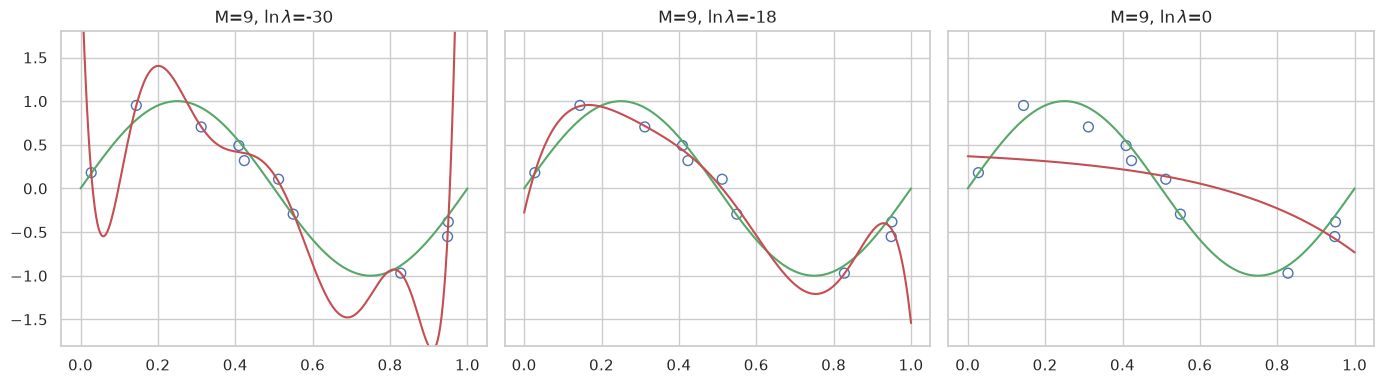

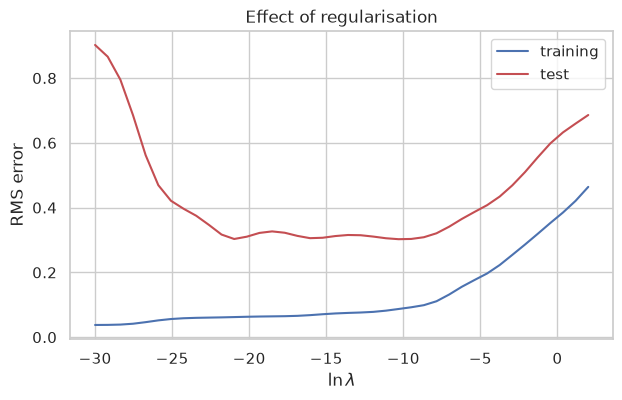

best ln(lambda) on test set: -10.3


In [5]:
def ridge_poly(x, t, M, lam):
    Phi = np.vander(x, M + 1, increasing=True)
    return np.linalg.solve(lam * np.eye(M + 1) + Phi.T @ Phi, Phi.T @ t)

def predict(w, x): return np.vander(x, len(w), increasing=True) @ w

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, ln_lam in zip(axes, [-30, -18, 0]):
    w = ridge_poly(x_train, t_train, 9, np.exp(ln_lam))
    ax.plot(x_line, np.sin(2 * np.pi * x_line), "g")
    ax.plot(x_line, predict(w, x_line), "r")
    ax.scatter(x_train, t_train, facecolors="none", edgecolors="b", s=50)
    ax.set_title(rf"M=9, $\ln\lambda$={ln_lam}"); ax.set_ylim(-1.8, 1.8)
plt.tight_layout(); plt.show()

# choose lambda on held-out data
lams = np.exp(np.linspace(-30, 2, 40))
tr = [np.sqrt(np.mean((predict(ridge_poly(x_train, t_train, 9, l), x_train) - t_train) ** 2)) for l in lams]
te = [np.sqrt(np.mean((predict(ridge_poly(x_train, t_train, 9, l), x_test) - t_test) ** 2)) for l in lams]
plt.figure(figsize=(7, 4)); plt.plot(np.log(lams), tr, "b", label="training"); plt.plot(np.log(lams), te, "r", label="test")
plt.xlabel(r"$\ln\lambda$"); plt.ylabel("RMS error"); plt.legend(); plt.title("Effect of regularisation"); plt.show()
print(f"best ln(lambda) on test set: {np.log(lams[np.argmin(te)]):.1f}")

### A3. Discrete random variables, Bayes' rule
Fundamental rules: **sum rule** $p(X)=\sum_Y p(X,Y)$, **product rule** $p(X,Y)=p(Y|X)p(X)$, and therefore
**Bayes' rule**

$$p(Y\mid X)=\frac{p(X\mid Y)\,p(Y)}{p(X)} .$$

*Example – a medical test.* Disease prevalence 1 %, sensitivity $p(+|D)=0.90$, specificity $p(-|\neg D)=0.95$.
What is $p(D\mid +)$? We compute it analytically and verify by Monte-Carlo simulation.

p(+)      = 0.0585
p(D | +)  = 0.1538   <- far lower than the 90% sensitivity!
simulated p(D | +) = 0.1537


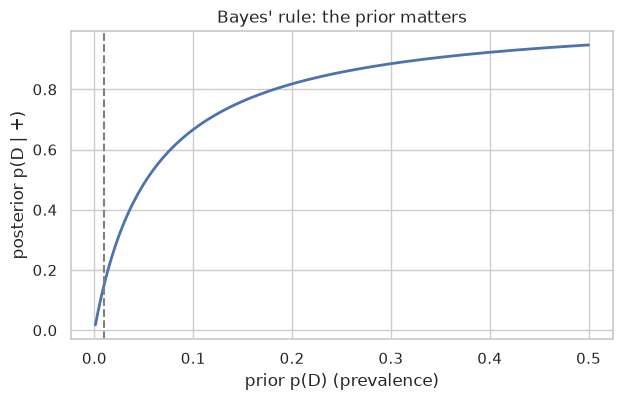

In [6]:
p_d, sens, spec = 0.01, 0.90, 0.95
p_pos = sens * p_d + (1 - spec) * (1 - p_d)          # sum rule
posterior = sens * p_d / p_pos                        # Bayes rule
print(f"p(+)      = {p_pos:.4f}")
print(f"p(D | +)  = {posterior:.4f}   <- far lower than the 90% sensitivity!")

# Monte-Carlo check
rng = np.random.default_rng(0)
N = 2_000_000
disease = rng.random(N) < p_d
positive = np.where(disease, rng.random(N) < sens, rng.random(N) > spec)
print(f"simulated p(D | +) = {disease[positive].mean():.4f}")

# posterior as a function of prevalence
prev = np.linspace(0.001, 0.5, 200)
post = sens * prev / (sens * prev + (1 - spec) * (1 - prev))
plt.figure(figsize=(7, 4)); plt.plot(prev, post, lw=2); plt.axvline(p_d, ls="--", c="gray")
plt.xlabel("prior p(D) (prevalence)"); plt.ylabel("posterior p(D | +)")
plt.title("Bayes' rule: the prior matters"); plt.show()

### A4. Independence and conditional independence
$X\perp Y \iff p(X,Y)=p(X)p(Y)$; $X\perp Y\mid Z \iff p(X,Y|Z)=p(X|Z)p(Y|Z)$.
Two variables can be **dependent marginally but independent given a common cause**.
Here a coin is picked at random (fair or biased, 50/50) and flipped twice: the flips are independent given the coin, yet dependent overall.

In [7]:
rng = np.random.default_rng(1)
N = 400_000
coin_biased = rng.random(N) < 0.5                       # Z
p_heads = np.where(coin_biased, 0.9, 0.5)
f1 = rng.random(N) < p_heads                            # X
f2 = rng.random(N) < p_heads                            # Y

def joint_vs_product(a, b, label):
    pa, pb, pab = a.mean(), b.mean(), (a & b).mean()
    print(f"{label:<28} p(X,Y)={pab:.4f}  p(X)p(Y)={pa*pb:.4f}  -> {'independent' if abs(pab-pa*pb)<2e-3 else 'DEPENDENT'}")

joint_vs_product(f1, f2, "marginal")
joint_vs_product(f1[coin_biased], f2[coin_biased], "given biased coin")
joint_vs_product(f1[~coin_biased], f2[~coin_biased], "given fair coin")

marginal                     p(X,Y)=0.5300  p(X)p(Y)=0.4900  -> DEPENDENT
given biased coin            p(X,Y)=0.8092  p(X)p(Y)=0.8091  -> independent
given fair coin              p(X,Y)=0.2501  p(X)p(Y)=0.2499  -> independent


### A5. Continuous random variables
A density $p(x)\ge 0$ with $\int p(x)dx=1$, CDF $P(x)=\int_{-\infty}^x p$, **quantile** $=P^{-1}(q)$.
For $\mathcal N(\mu,\sigma^2)$: $\mathbb E[x]=\mu$, $\mathrm{var}[x]=\sigma^2$.

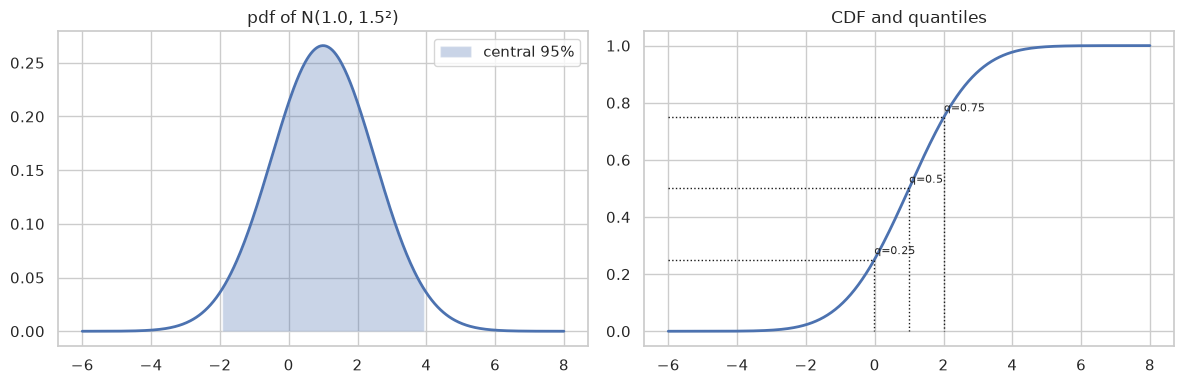

quantiles (25/50/75%):  theory [-0.012  1.     2.012]   sample [-0.014  1.     2.013]
mean  theory 1.0   sample 1.001
var   theory 2.25  sample 2.246
E[x^2] = var + mean^2 = 3.250   sample 3.248


In [8]:
mu, sigma = 1.0, 1.5
xs = np.linspace(-6, 8, 500)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(xs, stats.norm.pdf(xs, mu, sigma), lw=2)
lo, hi = stats.norm.ppf([0.025, 0.975], mu, sigma)
ax[0].fill_between(xs, stats.norm.pdf(xs, mu, sigma), where=(xs >= lo) & (xs <= hi), alpha=0.3, label="central 95%")
ax[0].set_title(f"pdf of N({mu}, {sigma}²)"); ax[0].legend()
ax[1].plot(xs, stats.norm.cdf(xs, mu, sigma), lw=2)
for q in [0.25, 0.5, 0.75]:
    xq = stats.norm.ppf(q, mu, sigma)
    ax[1].plot([xs[0], xq, xq], [q, q, 0], "k:", lw=1); ax[1].text(xq, q + 0.02, f"q={q}", fontsize=8)
ax[1].set_title("CDF and quantiles")
plt.tight_layout(); plt.show()

s = np.random.default_rng(3).normal(mu, sigma, 200_000)
print(f"quantiles (25/50/75%):  theory {stats.norm.ppf([.25,.5,.75], mu, sigma).round(3)}   sample {np.quantile(s, [.25,.5,.75]).round(3)}")
print(f"mean  theory {mu}   sample {s.mean():.3f}")
print(f"var   theory {sigma**2}  sample {s.var():.3f}")
print(f"E[x^2] = var + mean^2 = {sigma**2 + mu**2:.3f}   sample {np.mean(s**2):.3f}")

### A6. Expectation and covariance
$\mathrm{cov}[x,y]=\mathbb E[xy]-\mathbb E[x]\mathbb E[y]$. For a multivariate Gaussian the covariance matrix $\Sigma$ controls the
orientation and spread of the density contours (ellipses along the eigenvectors of $\Sigma$).

sample mean       : [0.996 1.999]  (true [1. 2.] )
sample covariance :
 [[1.954 1.16 ]
 [1.16  0.967]] 
(true
 [[2.  1.2]
 [1.2 1. ]] )
correlation coeff : 0.844  (true 0.849)


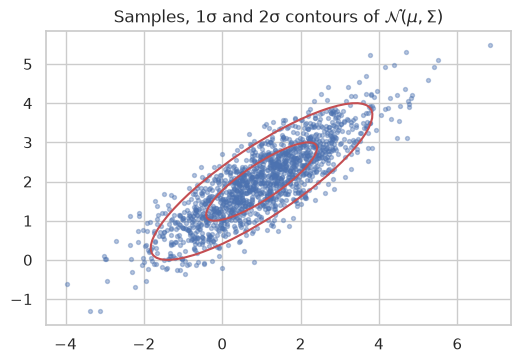

In [9]:
mean = np.array([1.0, 2.0])
Sigma = np.array([[2.0, 1.2], [1.2, 1.0]])
P = np.random.default_rng(4).multivariate_normal(mean, Sigma, 1500)

print("sample mean       :", P.mean(0).round(3), " (true", mean, ")")
print("sample covariance :\n", np.cov(P.T).round(3), "\n(true\n", Sigma, ")")
print("correlation coeff : %.3f  (true %.3f)" % (np.corrcoef(P.T)[0, 1], Sigma[0, 1] / np.sqrt(Sigma[0, 0] * Sigma[1, 1])))

from matplotlib.patches import Ellipse
vals, vecs = np.linalg.eigh(Sigma)
angle = np.degrees(np.arctan2(vecs[1, 1], vecs[0, 1]))
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(P[:, 0], P[:, 1], s=8, alpha=0.4)
for k in (1, 2):
    ax.add_patch(Ellipse(mean, 2 * k * np.sqrt(vals[1]), 2 * k * np.sqrt(vals[0]), angle=angle, fill=False, ec="r", lw=1.5))
ax.set_aspect("equal"); ax.set_title(r"Samples, 1σ and 2σ contours of $\mathcal{N}(\mu,\Sigma)$"); plt.show()

---
## Part B — Practice

## Practice 1 — Import, load and view a dataset
We will (i) load a dataset that ships with scikit-learn, (ii) export it to CSV, (iii) re-import it with `pandas.read_csv`
(this is the normal real-world path: *import → load → view*), and (iv) view it in table and graphical form.

In [10]:
# 1. Load a built-in dataset (Iris) into a DataFrame
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))
df = df.drop(columns="target")

# 2. Save it as CSV and import it back, as one would do with any external file
Path("data").mkdir(exist_ok=True)
df.to_csv("data/iris.csv", index=False)
df = pd.read_csv("data/iris.csv")
print("loaded from data/iris.csv")

# Other sources work the same way, e.g.
#   pd.read_csv("https://.../file.csv"), pd.read_excel("file.xlsx"), pd.read_json("file.json")

loaded from data/iris.csv


In [11]:
# 3. View the data
print("shape  :", df.shape)
print("columns:", list(df.columns))
display(df.head())
display(df.tail(3))
display(df.sample(5, random_state=0))
print(); df.info()

shape  : (150, 5)
columns: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
114,5.8,2.8,5.1,2.4,virginica
62,6.0,2.2,4.0,1.0,versicolor
33,5.5,4.2,1.4,0.2,setosa
107,7.3,2.9,6.3,1.8,virginica
7,5.0,3.4,1.5,0.2,setosa



<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


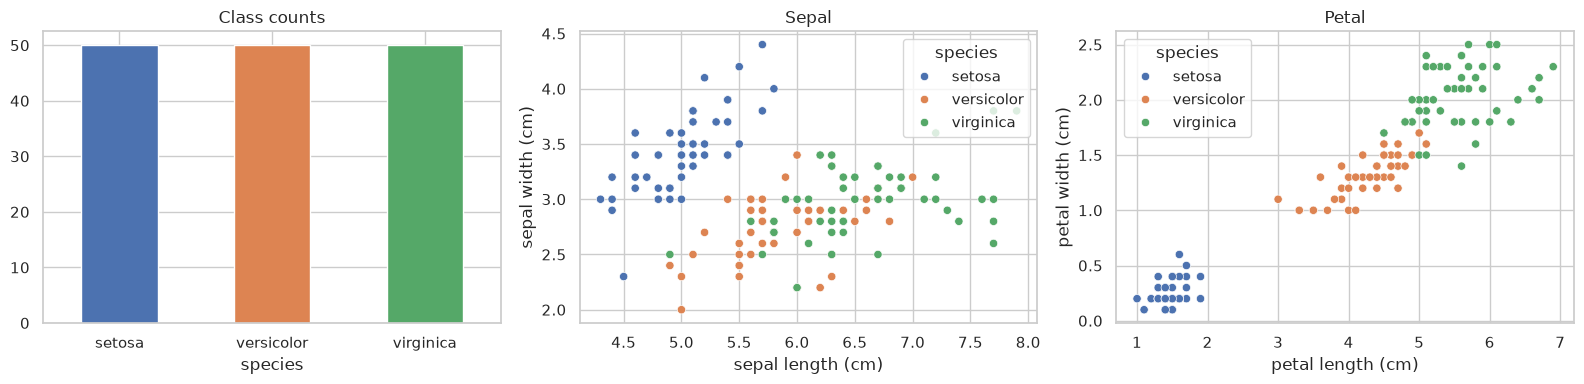

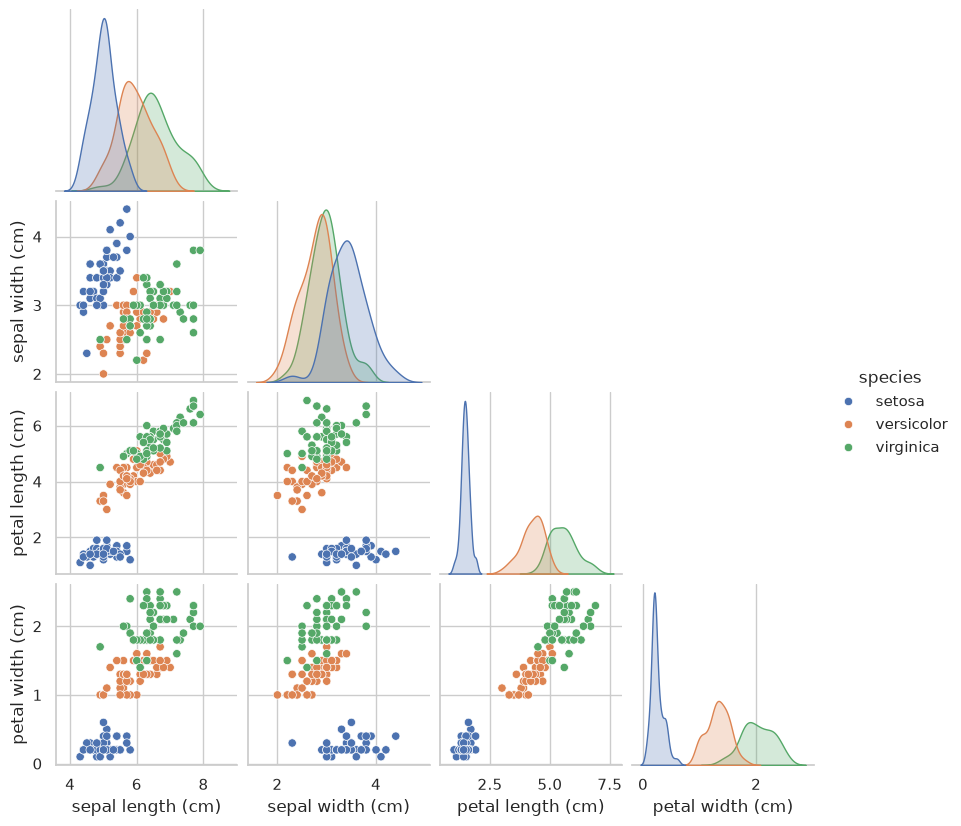

In [12]:
# 4. View it graphically
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
df["species"].value_counts().plot.bar(ax=ax[0], color=sns.color_palette()[:3], rot=0); ax[0].set_title("Class counts")
sns.scatterplot(data=df, x="sepal length (cm)", y="sepal width (cm)", hue="species", ax=ax[1]); ax[1].set_title("Sepal")
sns.scatterplot(data=df, x="petal length (cm)", y="petal width (cm)", hue="species", ax=ax[2]); ax[2].set_title("Petal")
plt.tight_layout(); plt.show()

sns.pairplot(df, hue="species", corner=True, height=2.1); plt.show()

## Practice 2 — Summary and statistics of the dataset
A reusable `summarize()` function reports: structure, missing values, duplicates, descriptive statistics
(count, mean, std, min, quartiles, max), skewness & kurtosis, per-class statistics, correlations and outliers, followed by plots.

In [13]:
def summarize(df, target=None):
    num = df.select_dtypes("number")
    print("=" * 60); print(f"Rows: {len(df)}   Columns: {df.shape[1]}   Duplicated rows: {df.duplicated().sum()}"); print("=" * 60)
    print("\n-- dtypes & missing values --")
    display(pd.DataFrame({"dtype": df.dtypes, "missing": df.isna().sum(), "missing %": (df.isna().mean() * 100).round(2), "unique": df.nunique()}))
    print("\n-- descriptive statistics (numeric) --")
    display(num.describe().T.assign(median=num.median(), var=num.var(), skew=num.skew(), kurtosis=num.kurt(),
                                   range=num.max() - num.min()).round(3))
    cat = df.select_dtypes(exclude="number")
    if not cat.empty:
        print("\n-- categorical columns --"); display(cat.describe().T)
    q1, q3 = num.quantile(.25), num.quantile(.75); iqr = q3 - q1
    outliers = ((num < q1 - 1.5 * iqr) | (num > q3 + 1.5 * iqr)).sum()
    print("\n-- outliers by 1.5*IQR rule --"); display(outliers.rename("n_outliers").to_frame().T)
    if target is not None:
        print(f"\n-- mean of each feature by '{target}' --"); display(df.groupby(target).mean(numeric_only=True).round(3))
        print(f"\n-- std of each feature by '{target}' --");  display(df.groupby(target).std(numeric_only=True).round(3))

summarize(df, target="species")

Rows: 150   Columns: 5   Duplicated rows: 1

-- dtypes & missing values --


,dtype,missing,missing %,unique
sepal length (cm),float64,0,0.0,35
sepal width (cm),float64,0,0.0,23
petal length (cm),float64,0,0.0,43
petal width (cm),float64,0,0.0,22
species,str,0,0.0,3



-- descriptive statistics (numeric) --


,count,mean,std,min,25%,50%,75%,max,median,var,skew,kurtosis,range
sepal length (cm),150.0,5.843,0.828,4.3,5.1,5.80,6.4,7.9,5.80,0.686,0.315,-0.552,3.6
sepal width (cm),150.0,3.057,0.436,2.0,2.8,3.00,3.3,4.4,3.00,0.190,0.319,0.228,2.4
petal length (cm),150.0,3.758,1.765,1.0,1.6,4.35,5.1,6.9,4.35,3.116,-0.275,-1.402,5.9
petal width (cm),150.0,1.199,0.762,0.1,0.3,1.30,1.8,2.5,1.30,0.581,-0.103,-1.341,2.4



-- categorical columns --


...

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
n_outliers,0,4,0,0



-- mean of each feature by 'species' --


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026



-- std of each feature by 'species' --


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,0.352,0.379,0.174,0.105
versicolor,0.516,0.314,0.470,0.198
virginica,0.636,0.322,0.552,0.275


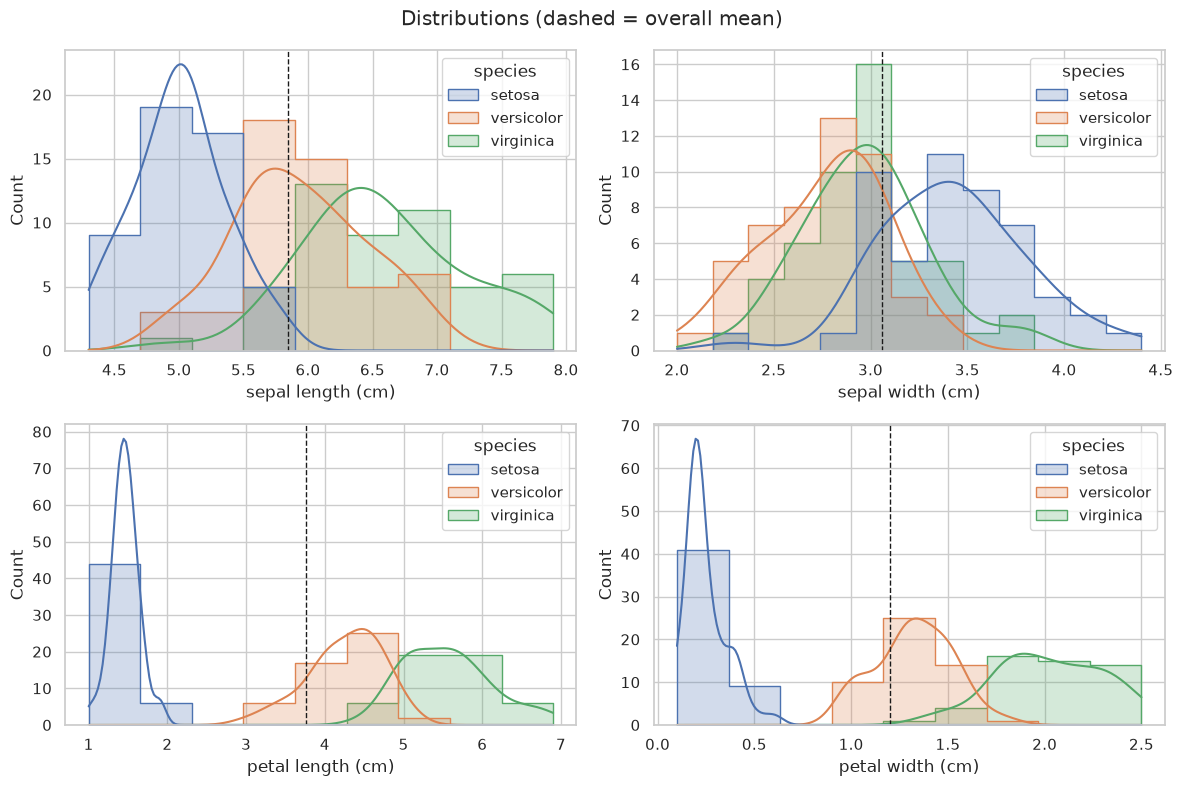

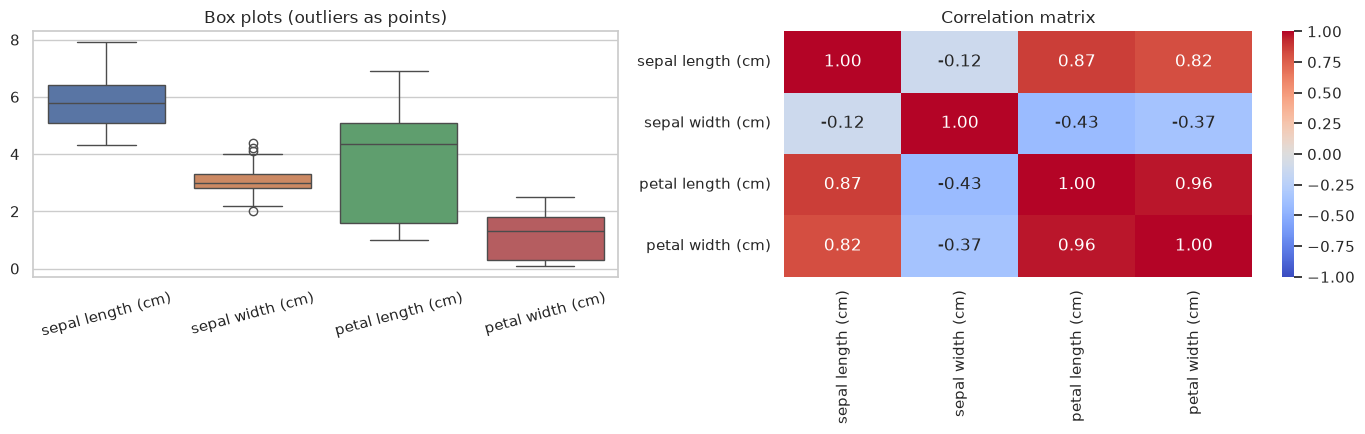

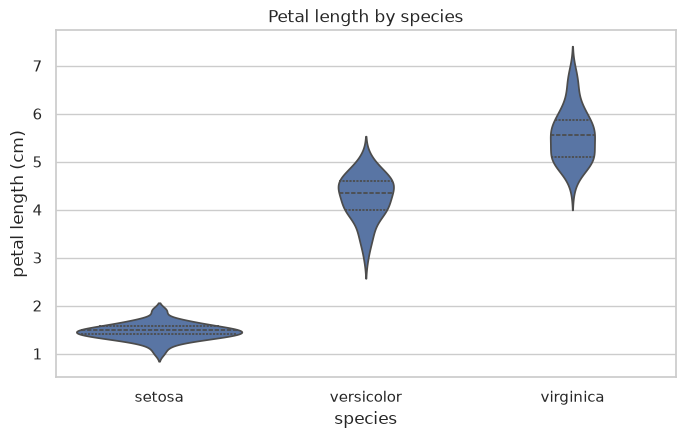

In [14]:
num = df.select_dtypes("number")
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
for a, col in zip(ax.ravel(), num.columns):
    sns.histplot(df, x=col, hue="species", kde=True, ax=a, element="step")
    a.axvline(df[col].mean(), c="k", ls="--", lw=1)
plt.suptitle("Distributions (dashed = overall mean)"); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(data=num, ax=ax[0]); ax[0].set_title("Box plots (outliers as points)"); ax[0].tick_params(axis="x", rotation=15)
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax[1]); ax[1].set_title("Correlation matrix")
plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 4.5))
sns.violinplot(data=df, x="species", y="petal length (cm)", inner="quartile"); plt.title("Petal length by species"); plt.show()

### Same function on a second dataset (Wine, 13 features)
Because `summarize()` is generic, the same call works on any DataFrame.

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,cultivar
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.00,0.81,11.03,12.36,13.05,13.68,14.83
malic_acid,178.0,2.34,1.12,0.74,1.60,1.87,3.08,5.80
ash,178.0,2.37,0.27,1.36,2.21,2.36,2.56,3.23
alcalinity_of_ash,178.0,19.49,3.34,10.60,17.20,19.50,21.50,30.00
magnesium,178.0,99.74,14.28,70.00,88.00,98.00,107.00,162.00
total_phenols,178.0,2.30,0.63,0.98,1.74,2.36,2.80,3.88
flavanoids,178.0,2.03,1.00,0.34,1.20,2.13,2.88,5.08
nonflavanoid_phenols,178.0,0.36,0.12,0.13,0.27,0.34,0.44,0.66
proanthocyanins,178.0,1.59,0.57,0.41,1.25,1.56,1.95,3.58
color_intensity,178.0,5.06,2.32,1.28,3.22,4.69,6.20,13.00


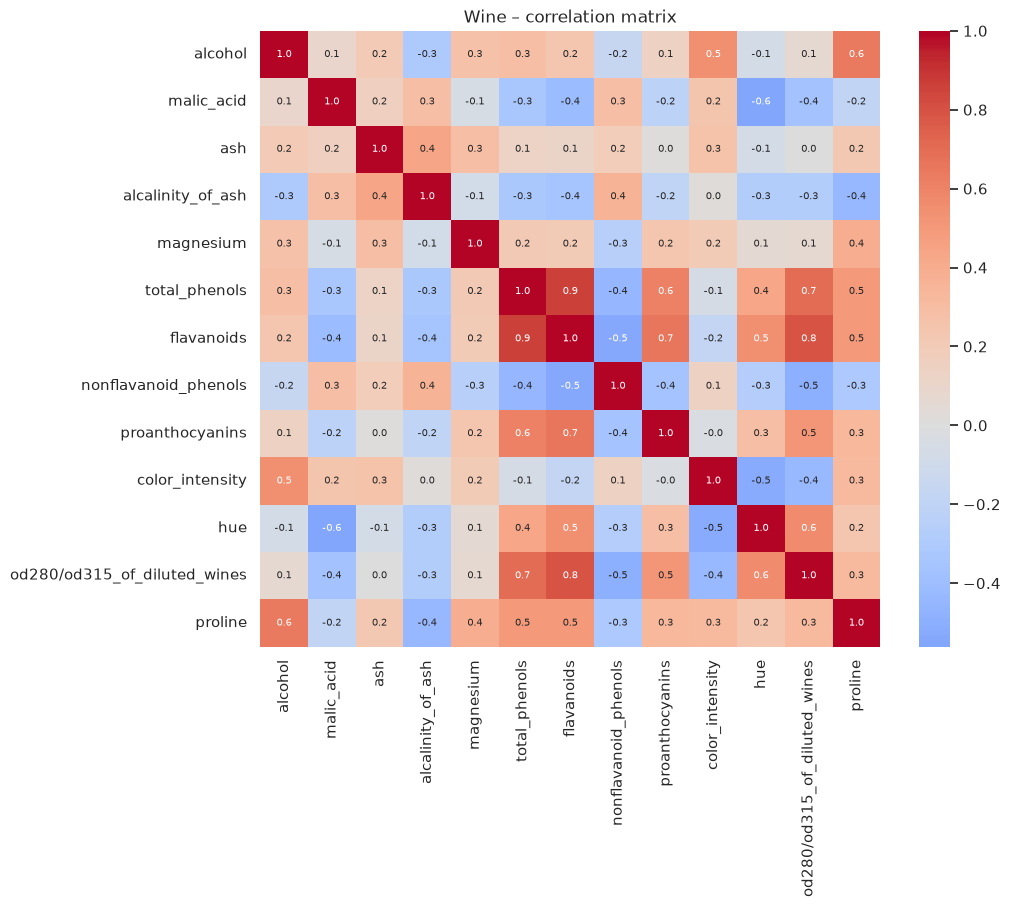

In [15]:
wine = load_wine(as_frame=True).frame
wine["cultivar"] = wine.pop("target").map({0: "class_0", 1: "class_1", 2: "class_2"})
display(wine.head(3))
display(wine.describe().T.round(2))
plt.figure(figsize=(10, 8))
sns.heatmap(wine.drop(columns="cultivar").corr(), cmap="coolwarm", center=0, annot=True, fmt=".1f", annot_kws={"size": 7})
plt.title("Wine – correlation matrix"); plt.show()

## Summary
* Learned the supervised / unsupervised distinction and saw over-fitting & regularisation in polynomial curve fitting.
* Verified Bayes' rule, (conditional) independence, quantiles, mean/variance and covariance numerically.
* Wrote loaders and a reusable summary/statistics routine for tabular datasets.